In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

In [3]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/brain-tumor-classification/models/best_model.keras"
)
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 140 variables whereas the saved optimizer has 144 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [4]:
def visualize_tumor_location(model, img_path, class_names, intensity=0.6, res=224):
    """
    Generates and overlays a Grad-CAM heatmap on an MRI image to visualize tumor location.
    """
    # 1) Load and preprocess image
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(res, res))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_show = img_array.astype("uint8")
    img_array_input = np.expand_dims(img_array, axis=0)

    # Preprocess specifically for EfficientNet
    preprocessed_input = tf.keras.applications.efficientnet.preprocess_input(img_array_input.copy())

    # 2) Identify the base model and the target layer inside it
    base_model = model.get_layer("efficientnetb0")
    target_layer = base_model.get_layer("top_activation")

    # 3) Create a Grad-Model for the base model only
    # This maps base_model input -> [target_conv_layer, base_model_output]
    base_grad_model = tf.keras.Model(
        inputs=base_model.inputs,
        outputs=[target_layer.output, base_model.output]
    )

    # 4) Gradient Tape
    with tf.GradientTape() as tape:
        # Forward pass 1: Base Model
        conv_outputs, base_output = base_grad_model(preprocessed_input, training=False)

        # Forward pass 2: The model's head (GAP, BN, Dropout, Dense)
        x = model.get_layer("global_average_pooling2d")(base_output)
        x = model.get_layer("batch_normalization")(x)
        x = model.get_layer("dropout")(x)
        predictions = model.get_layer("dense")(x)

        # Target class prediction
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # 5) Gradients of the output class w.r.t. conv_outputs
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 6) Compute Heatmap
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # ReLU and Normalize
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    heatmap = tf.cast(heatmap, tf.float32).numpy()

    # 7) Resize and Overlay
    heatmap_resized = cv2.resize(heatmap, (res, res))
    heatmap_resized = cv2.GaussianBlur(heatmap_resized, (7, 7), 0)

    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(img_show, 1 - intensity, heatmap_color, intensity, 0)

    # 8) Plot
    pred_label = class_names[pred_index]
    conf_val = float(np.max(predictions[0]))

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1); plt.imshow(img_show); plt.title("Original MRI"); plt.axis("off")
    plt.subplot(1, 2, 2); plt.imshow(overlay); plt.title(f"Hot Region: {pred_label} ({conf_val:.2%})"); plt.axis("off")
    plt.tight_layout()
    plt.show()


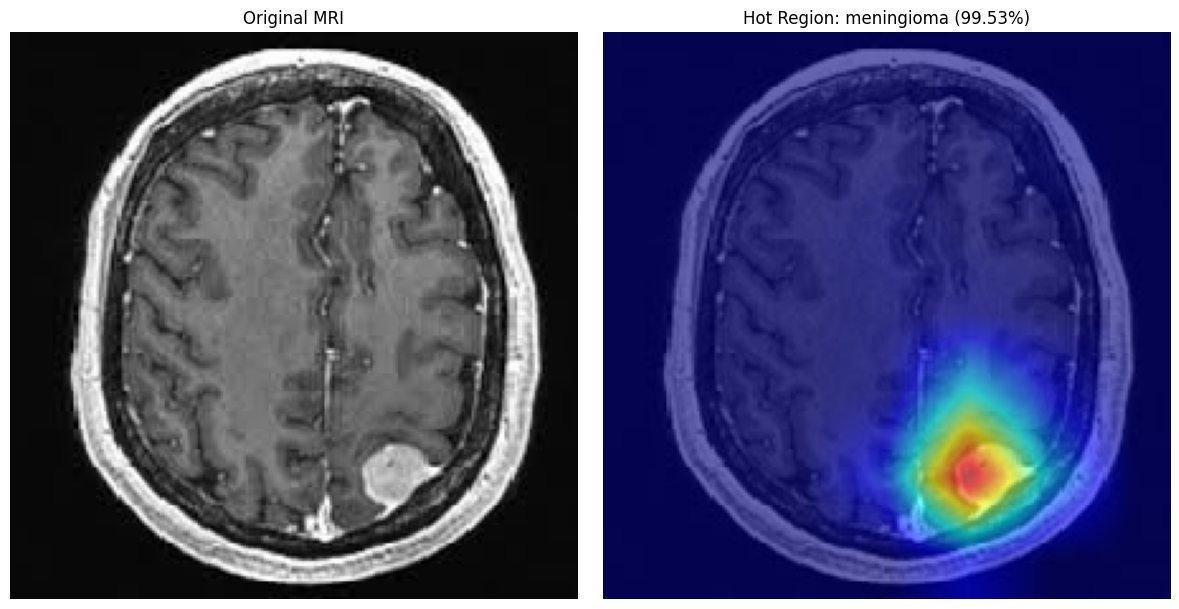

In [13]:
# Run visualization
visualize_tumor_location(model, "/content/images.jpg", class_names)